# **Exploration Data Analysis:**
**Import packages:**

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")

**Load Dataset:**

In [2]:
data_path = 'E:/Visual Studio Code/IML/Jahnavi_Neha_A1/retail_task/data/Retail.csv'
df = pd.read_csv(data_path)
print("Loaded Raw Dataset:", data_path)

Loaded Raw Dataset: E:/Visual Studio Code/IML/Jahnavi_Neha_A1/retail_task/data/Retail.csv


**Data Preview:**

In [3]:
df.head(5)

,age,gender,income_bracket,loyalty_program,membership_years,churned,marital_status,number_of_children,education_level,occupation,...,distance_to_store,holiday_season,season,weekend,customer_support_calls,email_subscriptions,app_usage,website_visits,social_media_engagement,days_since_last_purchase
0,41,Female,Medium,No,3,No,Married,0,Bachelor's,Employed,...,72.83,No,Summer,No,18,No,Medium,2,Medium,6
1,40,Female,High,Yes,4,Yes,Single,4,PhD,Employed,...,44.60,Yes,Fall,No,16,Yes,Low,17,Medium,137
2,48,Male,High,No,4,Yes,Married,3,Bachelor's,Unemployed,...,46.15,Yes,Winter,Yes,11,Yes,High,68,High,275
3,19,Male,Low,No,9,Yes,Divorced,3,Bachelor's,Retired,...,0.62,No,Fall,No,15,Yes,Medium,61,Low,182
4,53,Female,Low,Yes,8,No,Divorced,2,Master's,Employed,...,38.09,Yes,Fall,Yes,0,Yes,High,19,High,330


In [4]:
df.shape

(800000, 77)

In [5]:
df.info

<bound method DataFrame.info of         age  gender income_bracket loyalty_program  membership_years churned  \
0        41  Female         Medium              No                 3      No   
1        40  Female           High             Yes                 4     Yes   
2        48    Male           High              No                 4     Yes   
3        19    Male            Low              No                 9     Yes   
4        53  Female            Low             Yes                 8      No   
...     ...     ...            ...             ...               ...     ...   
799995   77   Other            Low             Yes                 0     Yes   
799996   49   Other            Low             Yes                 0      No   
799997   20    Male         Medium             Yes                 5      No   
799998   44   Other         Medium             Yes                 7     Yes   
799999   70  Female         Medium              No                 9     Yes   

       

In [6]:
df.describe()

,age,membership_years,number_of_children,transaction_id,product_id,quantity,unit_price,discount_applied,transaction_hour,week_of_year,...,product_return_rate,product_weight,product_shelf_life,promotion_id,customer_zip_code,store_zip_code,distance_to_store,customer_support_calls,website_visits,days_since_last_purchase
count,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,...,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000
mean,48.489880,4.498445,1.999791,499796.925741,4999.302701,5.003425,500.120805,0.250013,11.508469,26.501809,...,0.250098,5.056466,181.891146,499.726743,55002.041589,54963.376260,50.011425,9.498734,49.511601,182.076024
std,17.868101,2.872934,1.414198,288558.279459,2887.681227,2.583392,288.440234,0.144315,6.925024,15.005291,...,0.144413,2.857353,105.272243,288.542749,25981.823465,25975.911014,28.863479,5.761851,28.864197,105.348022
min,18.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.100000,0.000000,1.000000,10000.000000,10000.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,2.000000,1.000000,249944.000000,2495.000000,3.000000,250.130000,0.130000,5.000000,14.000000,...,0.130000,2.580000,91.000000,250.000000,32464.000000,32484.000000,25.000000,4.000000,25.000000,91.000000
50%,49.000000,4.000000,2.000000,499641.500000,4999.000000,5.000000,500.120000,0.250000,12.000000,27.000000,...,0.250000,5.060000,182.000000,500.000000,54997.000000,54933.000000,50.010000,9.000000,50.000000,182.000000
75%,64.000000,7.000000,3.000000,749525.250000,7501.000000,7.000000,749.940000,0.370000,18.000000,39.000000,...,0.380000,7.530000,273.000000,750.000000,77507.000000,77442.000000,74.990000,14.000000,75.000000,273.000000
max,79.000000,9.000000,4.000000,999999.000000,9999.000000,9.000000,1000.000000,0.500000,23.000000,52.000000,...,0.500000,10.000000,364.000000,999.000000,99998.000000,99998.000000,100.000000,19.000000,99.000000,364.000000


In [7]:
df.size

61600000

# Explaining the data set:

**Handling missing values:**

In [8]:
missing = df.isnull().sum()
missing_p = (missing / len(df)) * 100

missing_data = pd.DataFrame({
    'Missing Values': missing,
    'Missing Percentage': missing_p
})

missing_data = missing_data[missing_data['Missing Values'] > 0]
missing_data = missing_data.sort_values(by='Missing Percentage', ascending=False)
print(missing_data)

Empty DataFrame
Columns: [Missing Values, Missing Percentage]
Index: []


Dataset is complete! No null values found.

**Encoding:**

In [9]:
thresh = 1000
object_cols = df.select_dtypes(include='object').columns
Large = [col for col in object_cols if df[col].nunique() > thresh]

print("Dropping high-cardinality (likely date) columns:\n", Large)
df = df.drop(columns=Large)
df= df.drop(["total_sales", "total_transactions", "total_items_purchased","avg_transaction_value", "max_single_purchase_value",
              "min_single_purchase_value"], axis=1)  # drops synonymous columns to the target variable, to prevent leakage 
 

Dropping high-cardinality (likely date) columns:
 ['transaction_date', 'last_purchase_date', 'product_manufacture_date', 'product_expiry_date', 'promotion_start_date', 'promotion_end_date']


In [10]:
object_cols = df.select_dtypes(include='object').columns
print("Remaining object columns:", object_cols)

Remaining object columns: Index(['gender', 'income_bracket', 'loyalty_program', 'churned',
       'marital_status', 'education_level', 'occupation', 'product_category',
       'payment_method', 'store_location', 'day_of_week', 'purchase_frequency',
       'preferred_store', 'product_name', 'product_brand', 'product_size',
       'product_color', 'product_material', 'promotion_type',
       'promotion_effectiveness', 'promotion_channel',
       'promotion_target_audience', 'customer_city', 'customer_state',
       'store_city', 'store_state', 'holiday_season', 'season', 'weekend',
       'email_subscriptions', 'app_usage', 'social_media_engagement'],
      dtype='object')


In [11]:
df_encoded = pd.get_dummies(df, columns=object_cols, drop_first=True).astype(int)
print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)

Shape before encoding: (800000, 65)
Shape after encoding: (800000, 110)


In [12]:
df=df_encoded.copy()        
print(df.head())       

   age  membership_years  number_of_children  transaction_id  product_id  \
0   41                 3                   0          237855         997   
1   40                 4                   4          500661        2869   
2   48                 4                   3          432552        6172   
3   19                 9                   3          771343        6004   
4   53                 8                   2          186219        3565   

   quantity  unit_price  discount_applied  transaction_hour  week_of_year  \
0         7         960                 0                 0            48   
1         5         219                 0                12            19   
2         8         759                 0                22             1   
3         9         862                 0                11            36   
4         3         609                 0                11            42   

   ...  holiday_season_Yes  season_Spring  season_Summer  season_Winter  \
0  ..

**Correlation:**

In [13]:
target="avg_purchase_value"
 #standardize with z score
num_cols = df.select_dtypes(include=["float", "float64", "float32"]).columns.tolist()
if target in num_cols:
    num_cols.remove(target)
    df[num_cols] = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()

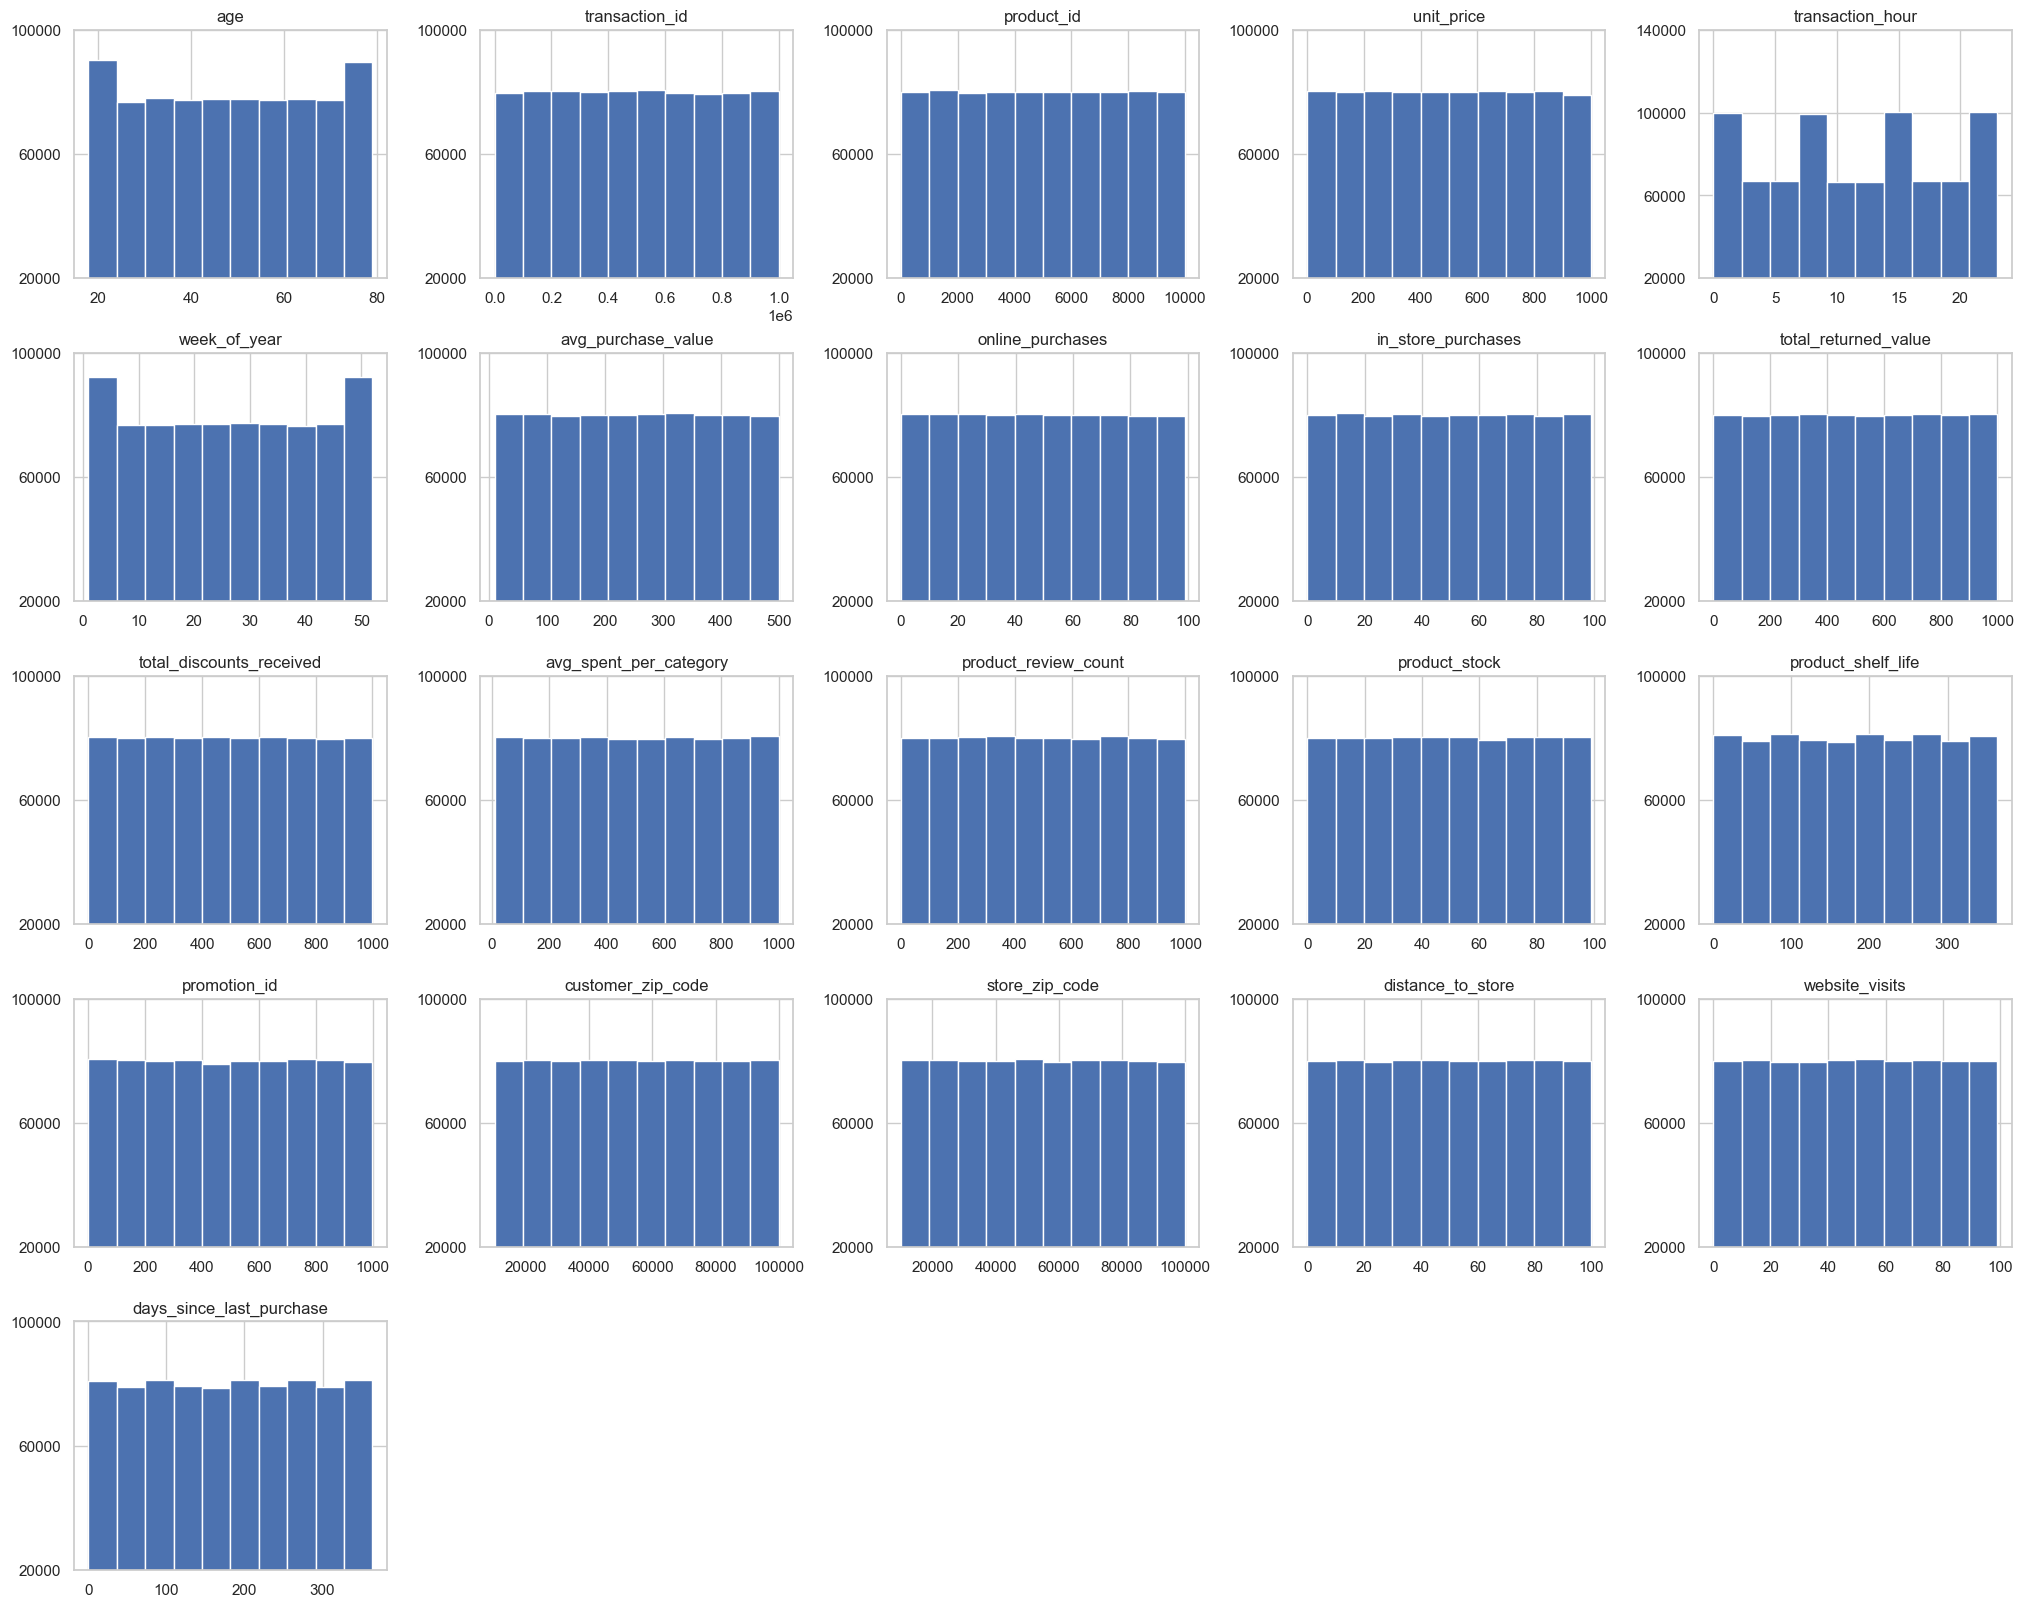

In [16]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
continuous_cols = [col for col in num_cols if (df[col].dtype == 'float') or (df[col].nunique() > 20)]
# doesnt pick encoded categorical
axes = df[continuous_cols].hist(figsize=(25, 20))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax in axes:
    ymin, ymax = ax.get_ylim()
    ymin = 20000
    ax.set_ylim(bottom=ymin)
    yticks = np.arange(ymin, ymax + 40000, 40000)
    ax.set_yticks(yticks)

plt.show()


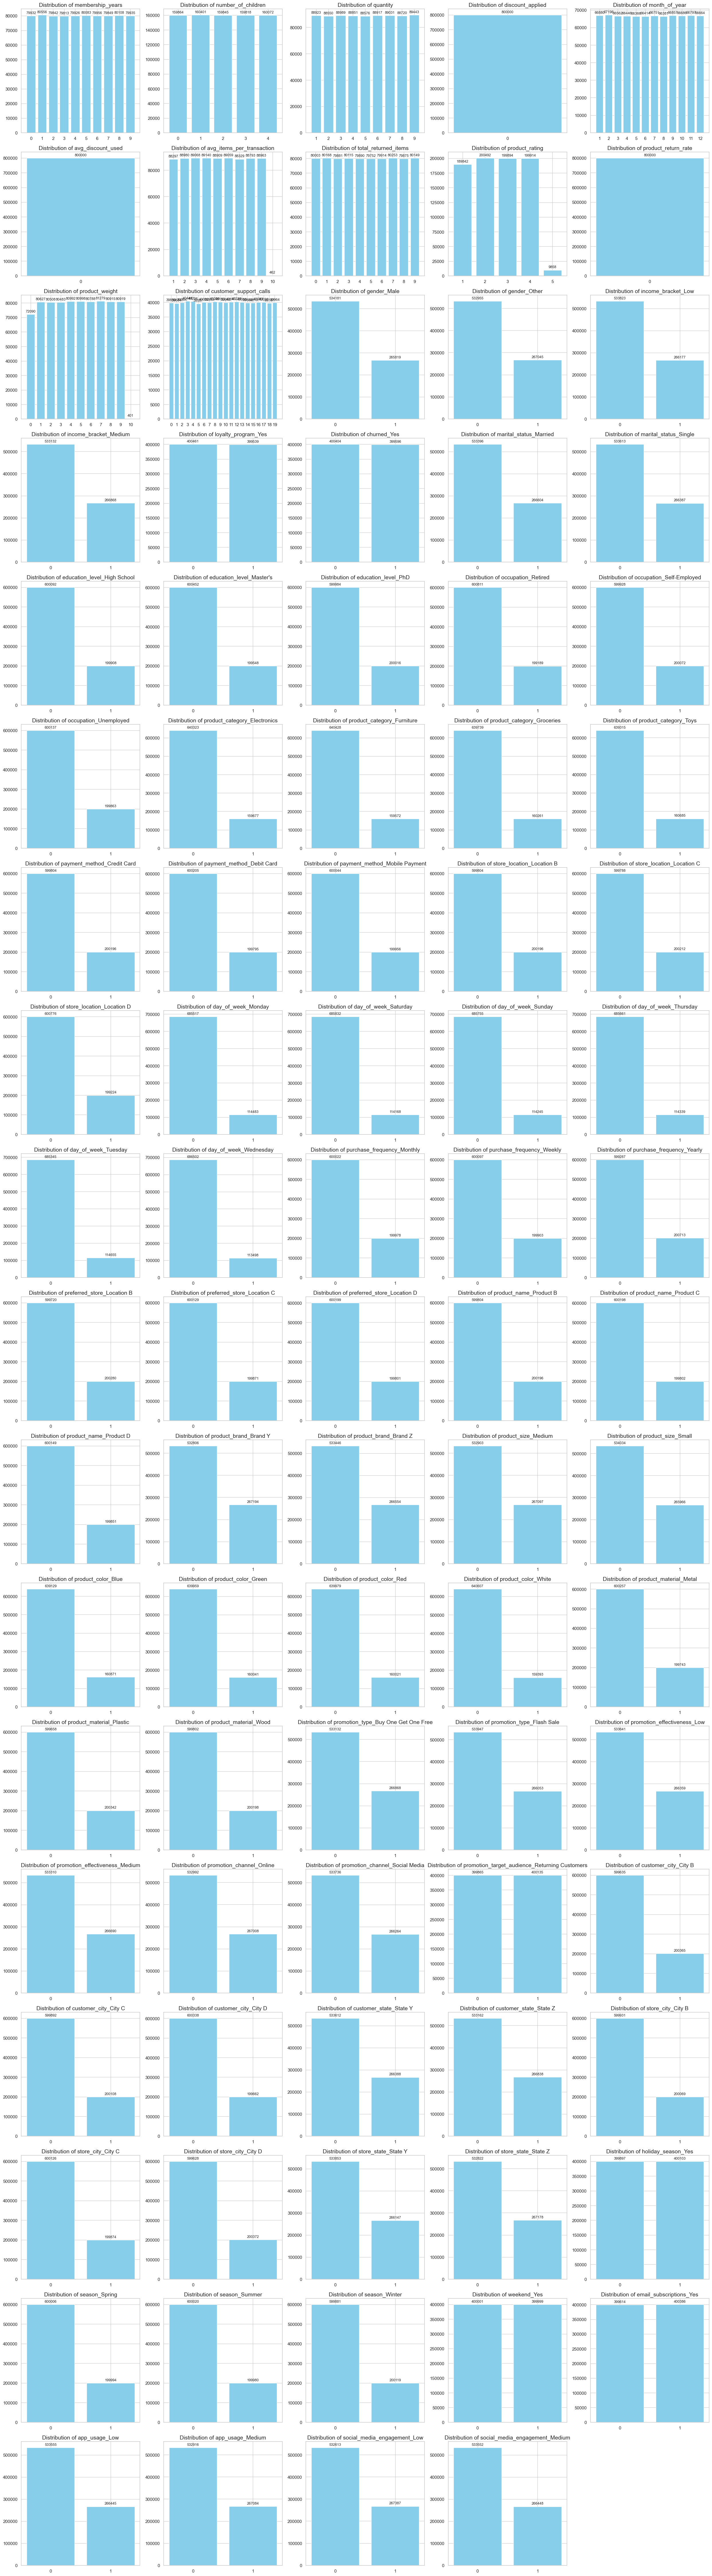

In [17]:
encoded_cat_cols = [col for col in num_cols if (df[col].nunique() <= 20) and (col not in continuous_cols)]

num_cols_plot = 5
num_plots = len(encoded_cat_cols)
num_rows = math.ceil(num_plots / num_cols_plot)

fig, axes = plt.subplots(num_rows, num_cols_plot, figsize=(num_cols_plot * 5, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(encoded_cat_cols):
    counts = df[col].value_counts().sort_index()
    bars = axes[i].bar(counts.index.astype(str), counts.values, color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    for bar in bars:
        height = bar.get_height()
        axes[i].annotate(f'{int(height)}',
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom',
                         fontsize=9)

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [18]:
df.select_dtypes(include='object').nunique().sort_values()

Series([], dtype: float64)

In [22]:
categorical_cols = df.select_dtypes(include='int').columns.tolist()
if 'avg_purchase_value' in continuous_cols:
    continuous_cols.remove('avg_purchase_value')
if 'avg_purchase_value' in categorical_cols:
    categorical_cols.remove('avg_purchase_value')

# Calculate correlations for numerical columns only
num_corr = df[continuous_cols + ['avg_purchase_value']].corr(numeric_only=True)['avg_purchase_value'].drop('avg_purchase_value').sort_values(ascending=False)
top_20_num = num_corr.head(20)
print("Top 20 Positive Correlations (Numerical):\n", top_20_num)



Top 20 Positive Correlations (Numerical):
 in_store_purchases          0.002483
transaction_id              0.001728
website_visits              0.001528
customer_zip_code           0.001294
days_since_last_purchase    0.000979
product_review_count        0.000957
week_of_year                0.000858
product_stock               0.000559
age                         0.000228
product_shelf_life          0.000182
store_zip_code              0.000173
product_id                 -0.000023
avg_spent_per_category     -0.000199
total_returned_value       -0.000408
promotion_id               -0.000738
unit_price                 -0.000843
transaction_hour           -0.001082
total_discounts_received   -0.001357
online_purchases           -0.002127
distance_to_store          -0.002444
Name: avg_purchase_value, dtype: float64


In [23]:
# Calculate correlations for encoded categorical columns only
cat_corr = df[categorical_cols + ['avg_purchase_value']].corr(numeric_only=True)['avg_purchase_value'].drop('avg_purchase_value').sort_values(ascending=False)
top_20_cat = cat_corr.head(20)
bottom_20_cat = cat_corr.tail(20)

print("\nTop 20 Positive Correlations (Categorical):\n", top_20_cat)
print("\nBottom 20 Negative Correlations (Categorical):\n", bottom_20_cat)


Top 20 Positive Correlations (Categorical):
 customer_city_City C              0.002578
total_returned_items              0.002509
in_store_purchases                0.002483
gender_Male                       0.002334
quantity                          0.002270
transaction_id                    0.001728
promotion_effectiveness_Medium    0.001641
store_state_State Y               0.001597
preferred_store_Location D        0.001556
website_visits                    0.001528
email_subscriptions_Yes           0.001499
product_material_Wood             0.001479
holiday_season_Yes                0.001477
day_of_week_Monday                0.001360
customer_zip_code                 0.001294
purchase_frequency_Monthly        0.001255
customer_state_State Y            0.001234
store_city_City D                 0.001158
payment_method_Mobile Payment     0.001143
day_of_week_Tuesday               0.001092
Name: avg_purchase_value, dtype: float64

Bottom 20 Negative Correlations (Categorical):
 cust

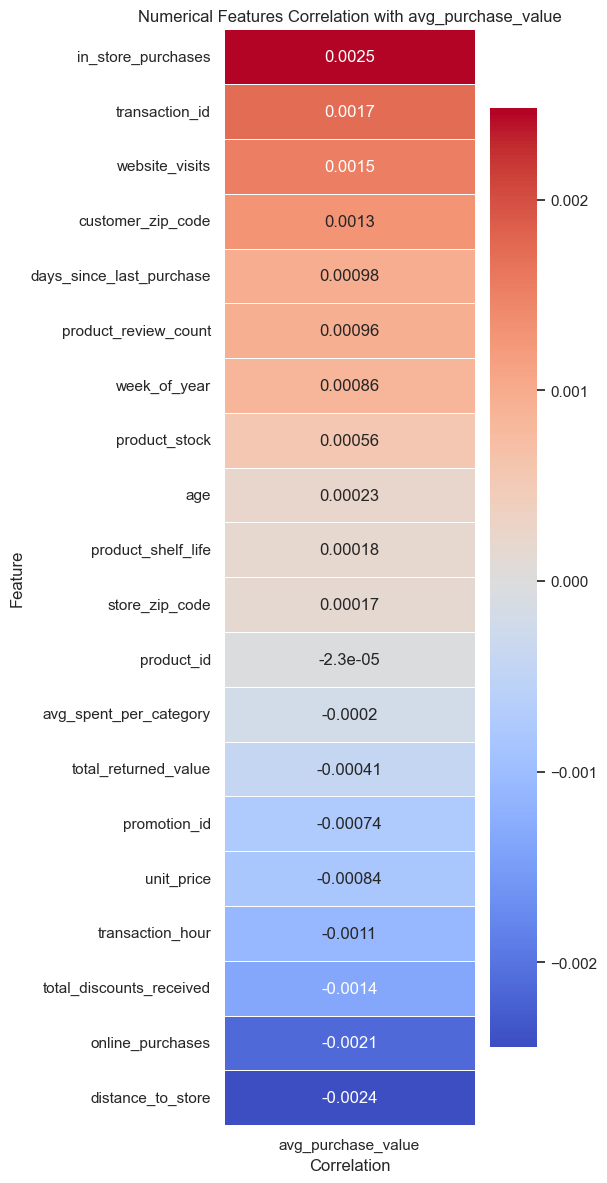

In [ ]:
target = 'avg_purchase_value'
# Prepare DataFrames for heatmaps: reshape so heatmap can work 
corr_num_df = pd.DataFrame(num_corr)

plt.figure(figsize=(6, len(corr_num_df) * 0.5 + 2))
sns.heatmap(corr_num_df, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title(f'Numerical Features Correlation with {target}')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


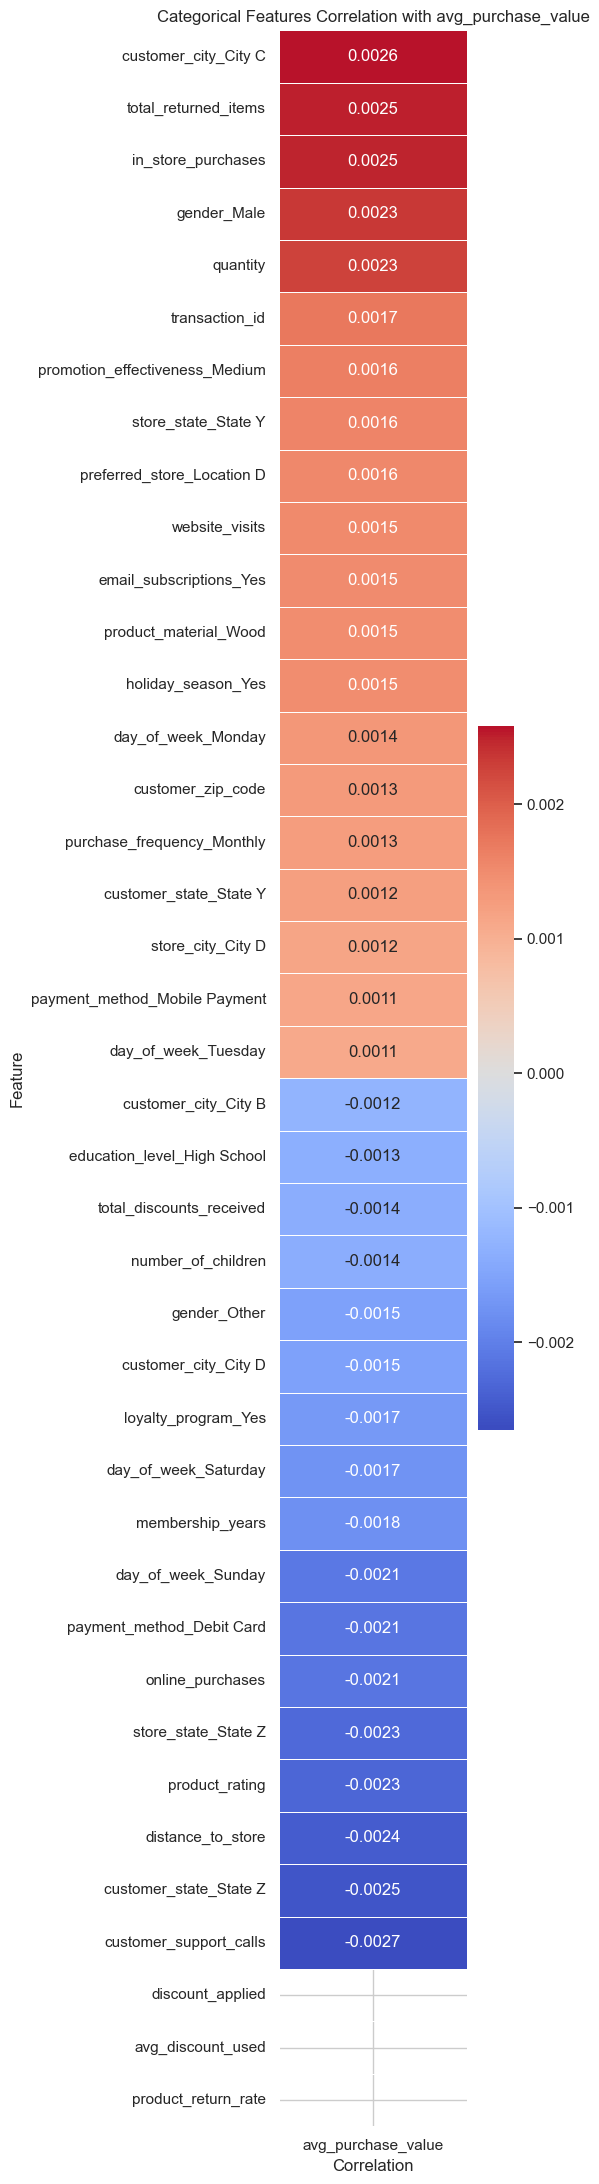

In [26]:
# Concatenate top and bottom correlations for categorical columns
corr_cat = pd.concat([top_20_cat, bottom_20_cat])
corr_cat_df = pd.DataFrame(corr_cat)

plt.figure(figsize=(6, len(corr_cat_df) * 0.5 + 2))
sns.heatmap(corr_cat_df, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title(f'Categorical Features Correlation with {target}')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Visualising data:**

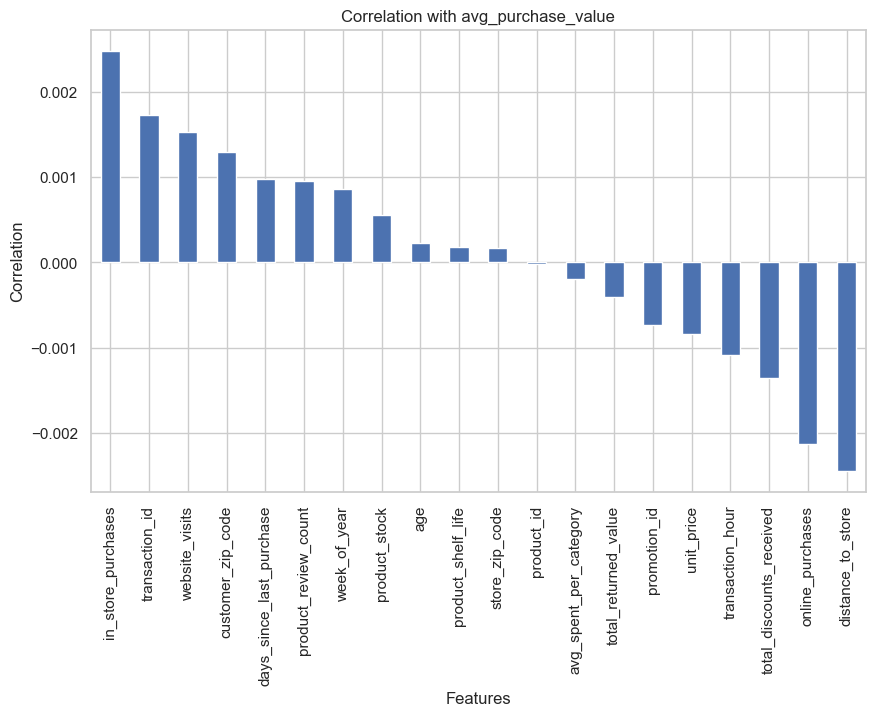

In [31]:
df['avg_purchase_value'] = pd.to_numeric(df['avg_purchase_value'], errors='coerce')
df_cleaned = df.dropna(subset=continuous_cols + ['avg_purchase_value'])
num_corr = df_cleaned[continuous_cols + ['avg_purchase_value']].corr(numeric_only=True)['avg_purchase_value'].drop('avg_purchase_value').sort_values(ascending=False)

# Plot the correlations
num_corr.plot(kind='bar', figsize=(10, 6))
plt.title("Correlation with avg_purchase_value")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.show()


When we chose a smaller sample space randomly, to find that all data values are scattered or are discrete. This shows how lightly the features are correlated with our target variable. 

# Insights:

* Overall correlations with "avg_purchase_value" are very weak, indicating no single dominant predictor.
* Slightly positive impact: "in_store_purchases" , "transaction_id", "website_visits", and "product_review_count" → engaged customers spend marginally more.
* Slightly negative impact: "distance_to_store", "online_purchases", "total_discounts_received", and "transaction_hour" → associated with lower average spend.
* Customer activity > demographics: Behavioral features (visits, reviews, purchases) matter slightly more than static ones (e.g., age, zip code).
* Since correlations are weak, advanced regression models are needed to capture complex, non-linear relationships.
